In [1]:
# ── Install dependencies (run once in Colab) ──────────────────────────────────
!pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels plotly --quiet

In [2]:
# ── Install / upgrade packages ────────────────────────────────────────────────
# Run this cell once; restart kernel if prompted
import subprocess, sys
pkgs = ['yfinance', 'pandas', 'numpy', 'matplotlib', 'seaborn',
        'scipy', 'statsmodels', 'ipywidgets', 'plotly']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + pkgs)
print('✅ All packages installed/verified.')

✅ All packages installed/verified.


In [3]:
import yfinance          as yf
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import matplotlib.gridspec as gridspec
import seaborn           as sns
from   scipy             import stats
from   statsmodels.regression.linear_model import OLS
from   statsmodels.tools import add_constant
import ipywidgets        as widgets
from   IPython.display   import display, HTML
import warnings, datetime, textwrap
warnings.filterwarnings('ignore')

# ── JupyterLab dark theme ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0d1117',
    'axes.facecolor'    : '#161b22',
    'axes.edgecolor'    : '#30363d',
    'axes.labelcolor'   : '#c9d1d9',
    'xtick.color'       : '#8b949e',
    'ytick.color'       : '#8b949e',
    'text.color'        : '#c9d1d9',
    'grid.color'        : '#21262d',
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.6,
    'legend.facecolor'  : '#161b22',
    'legend.edgecolor'  : '#30363d',
    'figure.dpi'        : 120,
    'font.size'         : 10,
})

# Colour palette
C = dict(
    blue   = '#58a6ff',
    green  = '#3fb950',
    red    = '#f85149',
    yellow = '#e3b341',
    purple = '#bc8cff',
    orange = '#d29922',
    white  = '#c9d1d9',
    grey   = '#484f58',
)

print('✅ Imports complete. JupyterLab theme applied.')

✅ Imports complete. JupyterLab theme applied.


In [5]:
TICKER      = 'EGP'           # EastGroup Properties
BENCHMARK   = 'VNQ'           # Vanguard Real Estate ETF  ← REIT-appropriate benchmark
START_DATE  = '2020-01-01'
END_DATE    = datetime.date.today().strftime('2026-02-20')

# ── Key events to study ────────────────────────────────────────────────────────
# Add / remove rows as needed: 'YYYY-MM-DD': 'Short label'
EVENTS = {
    '2020-02-19': 'Pre-COVID Peak',
    '2020-03-11': 'COVID-19 Pandemic Declared',
    '2020-03-23': 'Market Bottom (COVID)',
    '2020-03-27': 'CARES Act Signed',
    '2021-11-03': 'Fed Taper Announcement',
    '2022-03-16': 'First Fed Rate Hike (2022)',
    '2022-06-15': 'Fed +75bps Hike',
    '2022-10-13': 'CPI Surprise / Market Low',
    '2023-03-10': 'SVB Bank Collapse',
    '2023-09-20': 'Fed Holds (Higher-for-Longer)',
    '2024-09-18': 'Fed First Rate Cut (2024)',
    '2025-01-29': 'Fed Holds Rates (2025 Q1)',
    '2025-04-02': 'Trump announced Tariffs',
    '2026-02-05': 'Earnings Call',
    '2026-02-20': 'Supreme Court ruled out Tariffs'
}

# ── Event Study Windows ────────────────────────────────────────────────────────
PRE_WINDOW   = 10    # trading days before event
POST_WINDOW  = 10   # trading days after event
ESTIM_WINDOW = 25   # estimation window (days before pre-event window)

# ── Monte Carlo ────────────────────────────────────────────────────────────────
N_SIMULATIONS   = 10_000
FORECAST_DAYS   = 252          # ~1 trading year
INITIAL_PRICE   = None         # None = use latest close automatically
VaR_LEVELS      = [0.90, 0.95, 0.99]

print(f'  Ticker     : {TICKER} (EastGroup Properties)')
print(f'  Benchmark  : {BENCHMARK} (Vanguard Real Estate ETF)')
print(f'  Period     : {START_DATE}  →  {END_DATE}')
print(f'  Events     : {len(EVENTS)}')
print(f'  MC Sims    : {N_SIMULATIONS:,}  |  Horizon: {FORECAST_DAYS} trading days')

  Ticker     : EGP (EastGroup Properties)
  Benchmark  : VNQ (Vanguard Real Estate ETF)
  Period     : 2020-01-01  →  2026-02-20
  Events     : 15
  MC Sims    : 10,000  |  Horizon: 252 trading days


In [6]:
# ── Download data ──────────────────────────────────────────────────────────────
print('Downloading price data...')
raw_egp = yf.download(TICKER,    start=START_DATE, end=END_DATE,
                      auto_adjust=True, progress=False)
raw_vnq = yf.download(BENCHMARK, start=START_DATE, end=END_DATE,
                      auto_adjust=True, progress=False)

egp_close = raw_egp['Close'].squeeze().dropna()
vnq_close = raw_vnq['Close'].squeeze().dropna()

# Log returns
egp_ret = np.log(egp_close / egp_close.shift(1)).dropna()
vnq_ret = np.log(vnq_close / vnq_close.shift(1)).dropna()

# Align on common trading dates
common  = egp_ret.index.intersection(vnq_ret.index)
egp_ret = egp_ret.loc[common]
vnq_ret = vnq_ret.loc[common]

if INITIAL_PRICE is None:
    INITIAL_PRICE = float(egp_close.iloc[-1])

print(f'✅ {TICKER}  — {len(egp_close):,} observations  |  Last close = ${INITIAL_PRICE:.2f}')
print(f'✅ {BENCHMARK} — {len(vnq_close):,} observations  |  Last close = ${float(vnq_close.iloc[-1]):.2f}')
print(f'   Common trading days : {len(common):,}')
print(f'   Date range          : {common[0].date()} → {common[-1].date()}')

✅ EGP  — 1,541 observations  |  Last close = $190.64
✅ VNQ — 1,541 observations  |  Last close = $94.17
   Common trading days : 1,540
   Date range          : 2020-01-03 → 2026-02-19


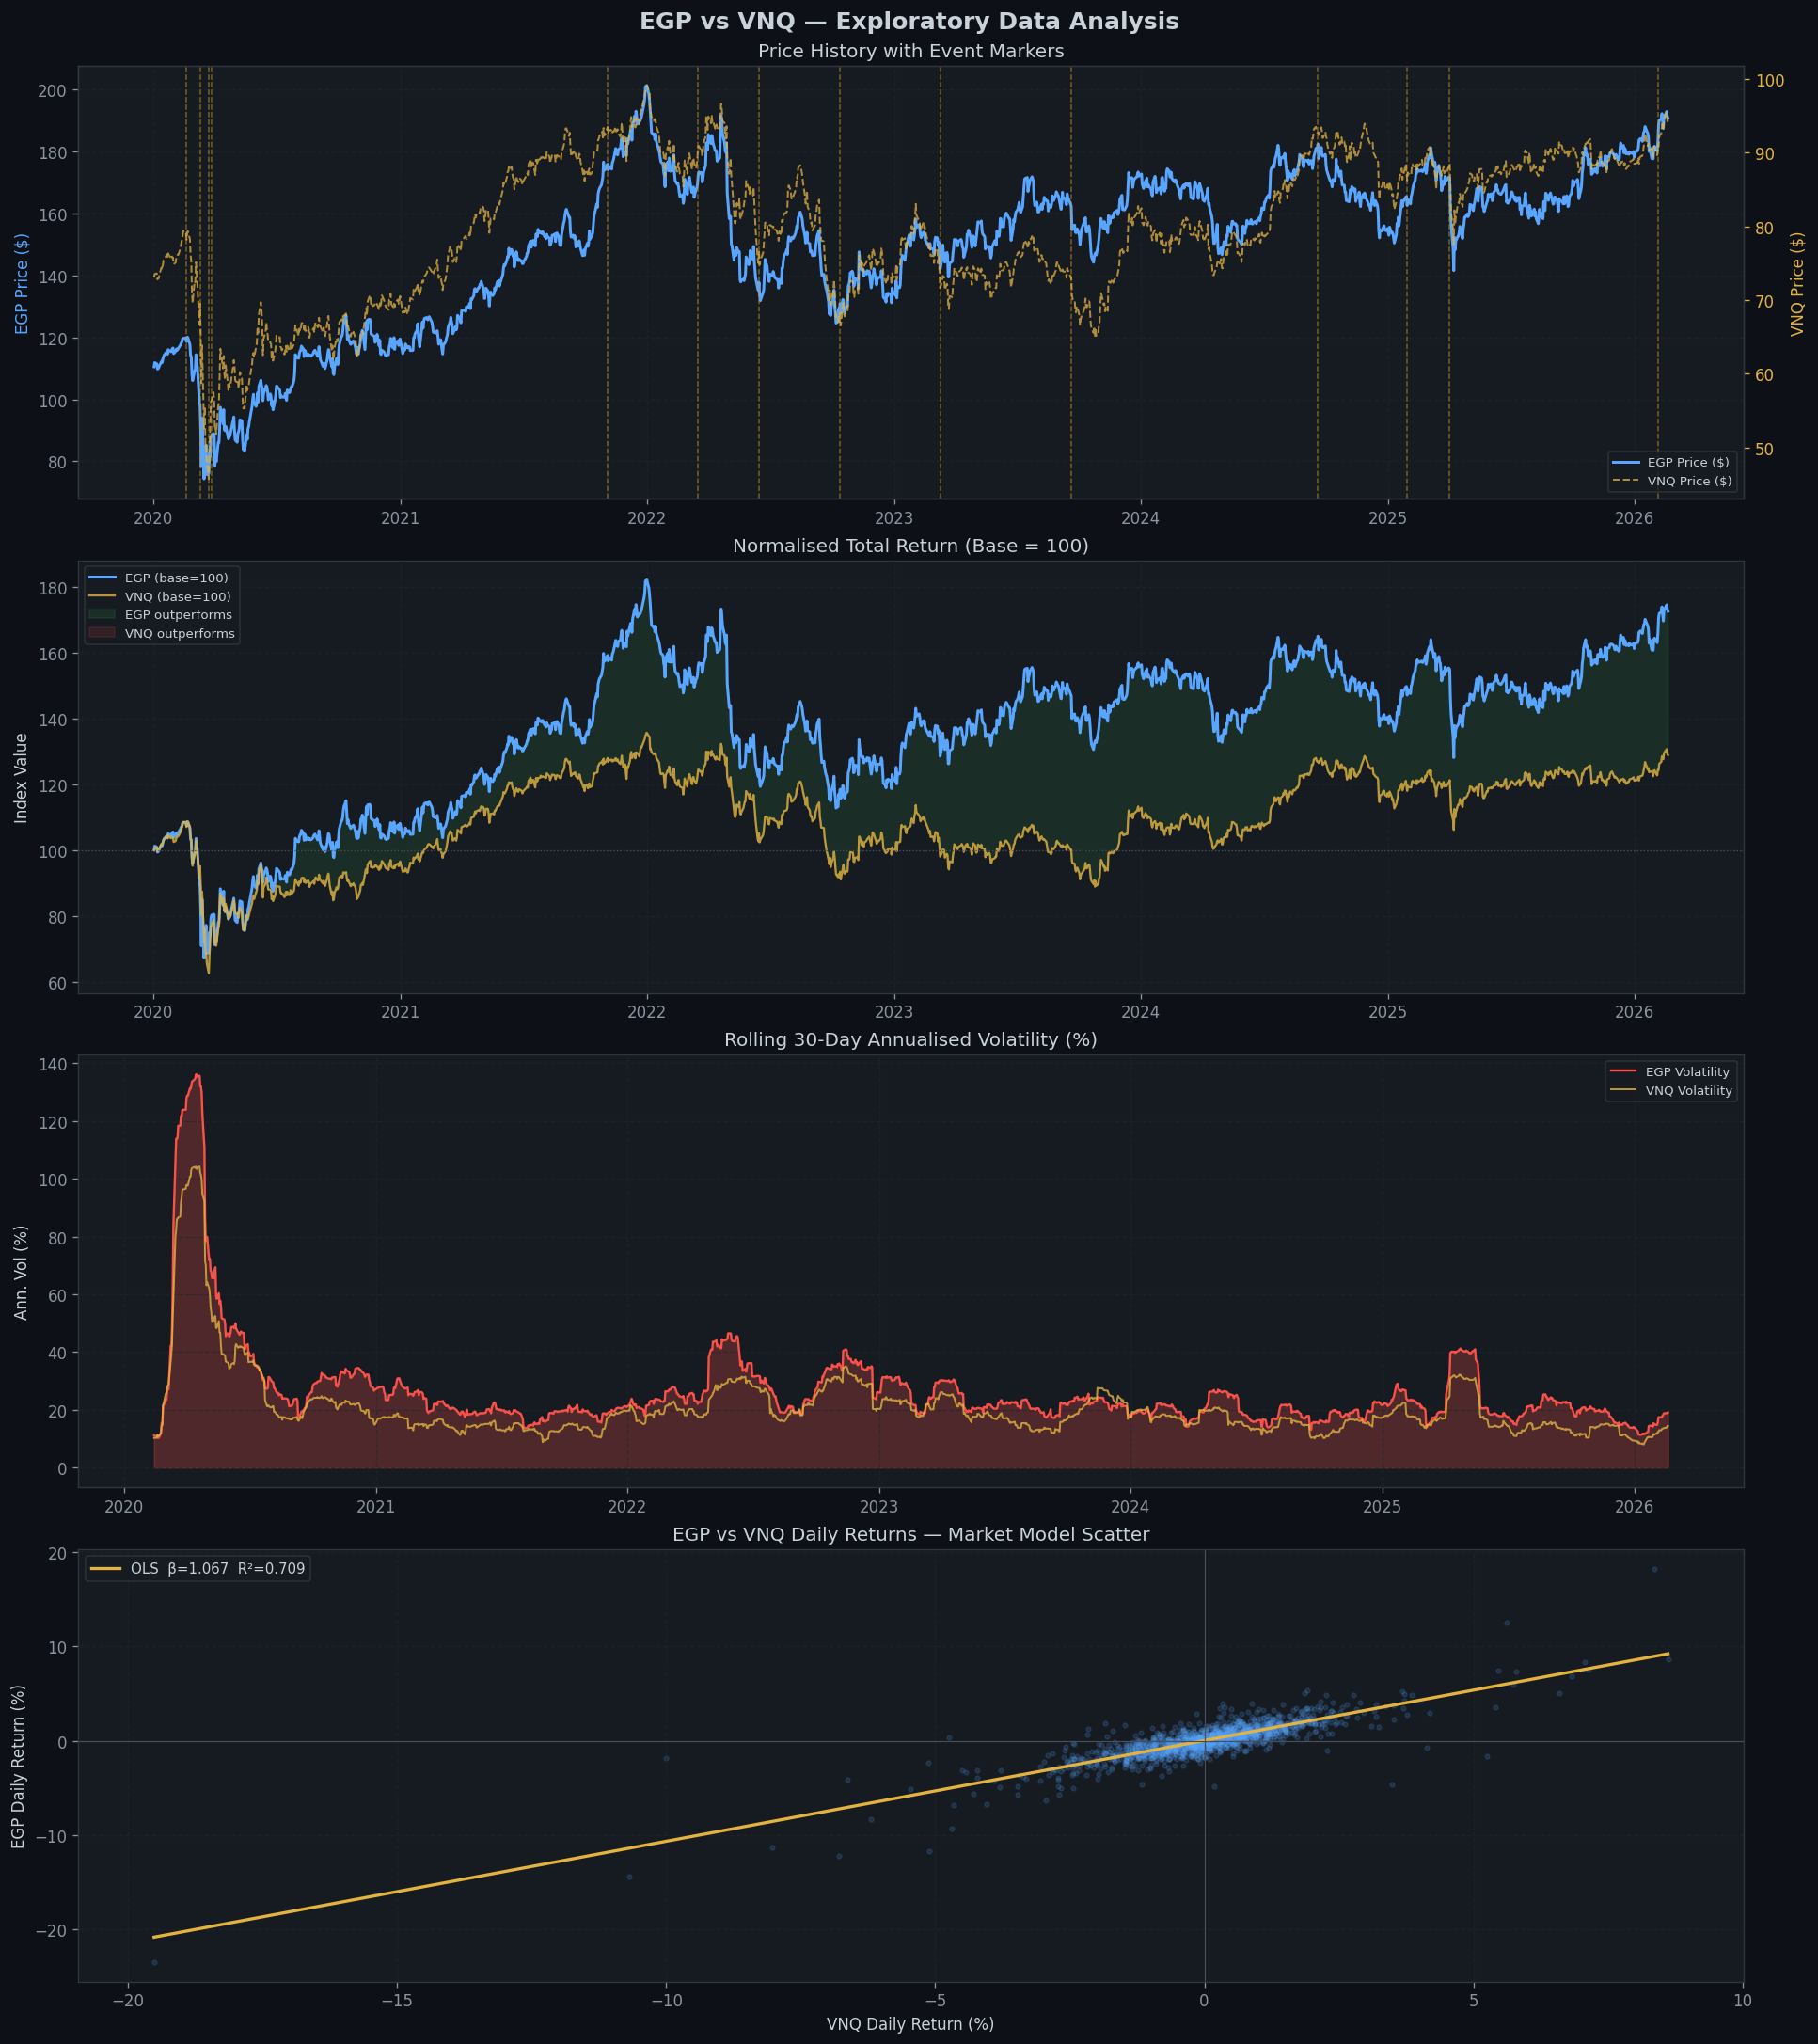

✅ EDA chart saved → EGP_EDA.png


In [7]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18), constrained_layout=True)
fig.suptitle(f'{TICKER} vs {BENCHMARK} — Exploratory Data Analysis',
             fontsize=15, fontweight='bold', color=C['white'])

# ── 1. Price history ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(egp_close.index, egp_close, color=C['blue'],   lw=1.8, label=f'{TICKER} Price ($)')
ax2_twin = ax.twinx()
ax2_twin.plot(vnq_close.index, vnq_close, color=C['yellow'], lw=1.2,
              alpha=0.75, linestyle='--', label=f'{BENCHMARK} Price ($)')
ax2_twin.set_ylabel(f'{BENCHMARK} Price ($)', color=C['yellow'])
ax2_twin.tick_params(colors=C['yellow'])
ax2_twin.set_facecolor('#161b22')
for dt_str in EVENTS:
    dt = pd.Timestamp(dt_str)
    if egp_close.index[0] <= dt <= egp_close.index[-1]:
        ax.axvline(dt, color=C['orange'], alpha=0.55, lw=0.9, linestyle='--')
ax.set_title('Price History with Event Markers', color=C['white'])
ax.set_ylabel(f'{TICKER} Price ($)', color=C['blue'])
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.grid(True); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── 2. Normalised total return ────────────────────────────────────────────────
ax = axes[1]
norm_egp = (egp_close / egp_close.iloc[0]) * 100
norm_vnq = (vnq_close / vnq_close.iloc[0]) * 100
ax.plot(norm_egp.index, norm_egp, color=C['blue'],   lw=1.8, label=f'{TICKER} (base=100)')
ax.plot(norm_vnq.index, norm_vnq, color=C['yellow'], lw=1.4, label=f'{BENCHMARK} (base=100)', alpha=0.8)
ax.fill_between(norm_egp.index, norm_egp, norm_vnq,
                where=(norm_egp >= norm_vnq), alpha=0.12, color=C['green'],
                interpolate=True, label=f'{TICKER} outperforms')
ax.fill_between(norm_egp.index, norm_egp, norm_vnq,
                where=(norm_egp < norm_vnq),  alpha=0.12, color=C['red'],
                interpolate=True, label=f'{BENCHMARK} outperforms')
ax.axhline(100, color=C['grey'], lw=0.8, linestyle=':')
ax.set_title('Normalised Total Return (Base = 100)', color=C['white'])
ax.set_ylabel('Index Value'); ax.legend(fontsize=8)
ax.grid(True); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── 3. Rolling 30-day Annualised Volatility ───────────────────────────────────
ax = axes[2]
roll_egp = egp_ret.rolling(30).std() * np.sqrt(252) * 100
roll_vnq = vnq_ret.rolling(30).std() * np.sqrt(252) * 100
ax.fill_between(roll_egp.index, roll_egp, alpha=0.25, color=C['red'])
ax.plot(roll_egp.index, roll_egp, color=C['red'],    lw=1.4, label=f'{TICKER} Volatility')
ax.plot(roll_vnq.index, roll_vnq, color=C['yellow'], lw=1.2, label=f'{BENCHMARK} Volatility', alpha=0.8)
ax.set_title('Rolling 30-Day Annualised Volatility (%)', color=C['white'])
ax.set_ylabel('Ann. Vol (%)'); ax.legend(fontsize=8)
ax.grid(True); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── 4. Scatter: EGP vs VNQ daily returns ─────────────────────────────────────
ax = axes[3]
ax.scatter(vnq_ret*100, egp_ret*100, alpha=0.15, s=8, color=C['blue'])
slope, intercept, r_val, p_val, _ = stats.linregress(vnq_ret, egp_ret)
x_line = np.linspace(vnq_ret.min(), vnq_ret.max(), 200)
ax.plot(x_line*100, (intercept + slope*x_line)*100,
        color=C['yellow'], lw=2, label=f'OLS  β={slope:.3f}  R²={r_val**2:.3f}')
ax.axhline(0, color=C['grey'], lw=0.7); ax.axvline(0, color=C['grey'], lw=0.7)
ax.set_title(f'{TICKER} vs {BENCHMARK} Daily Returns — Market Model Scatter', color=C['white'])
ax.set_xlabel(f'{BENCHMARK} Daily Return (%)'); ax.set_ylabel(f'{TICKER} Daily Return (%)')
ax.legend(fontsize=9); ax.grid(True)

plt.savefig('EGP_EDA.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ EDA chart saved → EGP_EDA.png')

In [11]:
# ── Descriptive Statistics (jinja2-free HTML table) ───────────────────────────
def make_stats(ret, close, name):
    roll_max = close.cummax()
    drawdown = (close - roll_max) / roll_max
    sharpe   = (ret.mean() / ret.std()) * np.sqrt(252)
    b, a, *_ = stats.linregress(vnq_ret, egp_ret) if name != BENCHMARK else (None, None)
    return {
        'Ticker':              name,
        'Ann. Return':         f"{ret.mean()*252*100:.2f}%",
        'Ann. Volatility':     f"{ret.std()*np.sqrt(252)*100:.2f}%",
        'Sharpe (rf=0)':       f"{sharpe:.3f}",
        'Skewness':            f"{ret.skew():.4f}",
        'Excess Kurtosis':     f"{ret.kurt():.4f}",
        'Max Drawdown':        f"{drawdown.min()*100:.2f}%",
        'Daily VaR 95%':       f"{np.percentile(ret, 5)*100:.4f}%",
        'Daily CVaR 95%':      f"{ret[ret <= np.percentile(ret,5)].mean()*100:.4f}%",
        'Beta vs VNQ':         f"{b:.4f}" if b is not None else '—',
        'Alpha vs VNQ (ann.)': f"{a*252*100:+.4f}%" if a is not None else '—',
    }

df_stats = pd.DataFrame([
    make_stats(egp_ret, egp_close, TICKER),
    make_stats(vnq_ret, vnq_close, BENCHMARK),
]).set_index('Ticker').T

# ── Render as styled HTML without requiring jinja2 / pandas .style ────────────
def df_to_html_table(df, title=''):
    TH  = 'background:#21262d;color:#c9d1d9;padding:8px 14px;text-align:left;border:1px solid #30363d'
    TD  = 'background:#161b22;color:#c9d1d9;padding:6px 14px;border:1px solid #21262d'
    TDH = 'background:#1c2128;color:#58a6ff;padding:6px 14px;border:1px solid #21262d;font-weight:600'
    rows = []
    # Header row
    header_cells = f'<th style="{TH}">Metric</th>' + ''.join(
        f'<th style="{TH}">{col}</th>' for col in df.columns
    )
    rows.append(f'<tr>{header_cells}</tr>')
    # Data rows
    for idx, row in df.iterrows():
        cells = f'<td style="{TDH}">{idx}</td>' + ''.join(
            f'<td style="{TD}">{v}</td>' for v in row
        )
        rows.append(f'<tr>{cells}</tr>')
    table = (
        f'<h4 style="color:#c9d1d9;font-family:sans-serif">{title}</h4>'
        f'<table style="border-collapse:collapse;font-family:monospace;font-size:12px">'
        + ''.join(rows)
        + '</table>'
    )
    return table

display(HTML(df_to_html_table(df_stats, '📊 Descriptive Statistics')))

Metric,EGP,VNQ
Ann. Return,8.93%,4.15%
Ann. Volatility,30.93%,24.39%
Sharpe (rf=0),0.289,0.170
Skewness,-1.1131,-1.5516
Excess Kurtosis,24.7155,22.7009
Max Drawdown,-38.10%,-42.40%
Daily VaR 95%,-2.6436%,-2.1938%
Daily CVaR 95%,-4.5221%,-3.6503%
Beta vs VNQ,1.0673,—
Alpha vs VNQ (ann.),+4.4979%,—


In [13]:
def run_event_study(event_date_str, stock_ret, bench_ret,
                    pre=PRE_WINDOW, post=POST_WINDOW, estim=ESTIM_WINDOW):
    """
    Market-model event study for a single event date.
    Returns dict with AR, CAR, t-stats, OLS params, or None if insufficient data.
    """
    all_dates = stock_ret.index
    event_ts  = pd.Timestamp(event_date_str)
    candidates = all_dates[all_dates >= event_ts]
    if len(candidates) == 0:
        return None
    event_ts = candidates[0]          # snap to nearest trading day
    pos      = all_dates.get_loc(event_ts)

    es = pos - pre - estim            # estimation start
    ee = pos - pre                    # estimation end
    ws = pos - pre                    # event-window start
    we = pos + post + 1               # event-window end

    if es < 0 or we > len(all_dates):
        return None

    # OLS estimation
    Y      = stock_ret.iloc[es:ee].values
    X      = add_constant(bench_ret.iloc[es:ee].values)
    model  = OLS(Y, X).fit()
    alpha, beta = model.params
    sigma  = np.std(model.resid, ddof=2)

    # Event window
    ev_dates   = all_dates[ws:we]
    actual_r   = stock_ret.iloc[ws:we].values
    bench_r    = bench_ret.iloc[ws:we].values
    expected_r = alpha + beta * bench_r
    AR         = actual_r - expected_r
    CAR        = np.cumsum(AR)
    t_stats    = AR / sigma if sigma > 0 else np.zeros_like(AR)

    # Benchmark CAR (raw)
    bench_CAR  = np.cumsum(bench_r)

    return {
        'event_date'   : event_ts,
        'alpha'        : alpha,
        'beta'         : beta,
        'r_squared'    : model.rsquared,
        'sigma'        : sigma,
        'relative_days': np.arange(-pre, post + 1),
        'ev_dates'     : ev_dates,
        'actual_ret'   : actual_r,
        'expected_ret' : expected_r,
        'bench_ret'    : bench_r,
        'AR'           : AR,
        'CAR'          : CAR,
        'bench_CAR'    : bench_CAR,
        't_stats'      : t_stats,
        'CAR_total'    : float(CAR[-1]),
        'AR_day0'      : float(AR[pre]),
        't_day0'       : float(t_stats[pre]),
    }

# ── Run all events ─────────────────────────────────────────────────────────────
results, skipped = {}, []
print(f'  Running event study  ({PRE_WINDOW} pre / {POST_WINDOW} post / {ESTIM_WINDOW} estim)\n')
for date_str, label in EVENTS.items():
    r = run_event_study(date_str, egp_ret, vnq_ret)
    if r:
        results[label] = r
        sig = '***' if abs(r['t_day0'])>2.576 else ('**' if abs(r['t_day0'])>1.96 else ('*' if abs(r['t_day0'])>1.645 else '  '))
        direction = '📈' if r['CAR_total'] > 0 else '📉'
        print(f'  ✅ {date_str}  {label:<38}  β={r["beta"]:+.3f}  '
              f'AR₀={r["AR_day0"]*100:+.2f}%{sig}  CAR={r["CAR_total"]*100:+.2f}% {direction}')
    else:
        skipped.append((date_str, label))
        print(f'  ⚠️  {date_str}  {label:<38}  Skipped (insufficient data)')

print(f'\n✅ Done — {len(results)} events processed, {len(skipped)} skipped')

  Running event study  (10 pre / 10 post / 25 estim)

  ⚠️  2020-02-19  Pre-COVID Peak                          Skipped (insufficient data)
  ✅ 2020-03-11  COVID-19 Pandemic Declared              β=+0.986  AR₀=-2.18%***  CAR=+4.09% 📈
  ✅ 2020-03-23  Market Bottom (COVID)                   β=+0.911  AR₀=+4.76%***  CAR=-0.83% 📉
  ✅ 2020-03-27  CARES Act Signed                        β=+1.121  AR₀=+1.68%    CAR=+21.17% 📈
  ✅ 2021-11-03  Fed Taper Announcement                  β=+1.101  AR₀=-0.45%    CAR=+1.66% 📈
  ✅ 2022-03-16  First Fed Rate Hike (2022)              β=+1.133  AR₀=-0.62%    CAR=+2.34% 📈
  ✅ 2022-06-15  Fed +75bps Hike                         β=+1.209  AR₀=-0.44%    CAR=+15.73% 📈
  ✅ 2022-10-13  CPI Surprise / Market Low               β=+0.973  AR₀=+0.37%    CAR=+6.54% 📈
  ✅ 2023-03-10  SVB Bank Collapse                       β=+0.767  AR₀=-1.28%    CAR=+1.05% 📈
  ✅ 2023-09-20  Fed Holds (Higher-for-Longer)           β=+0.871  AR₀=-0.52%    CAR=+0.09% 📈
  ✅ 2024-09-18  Fed

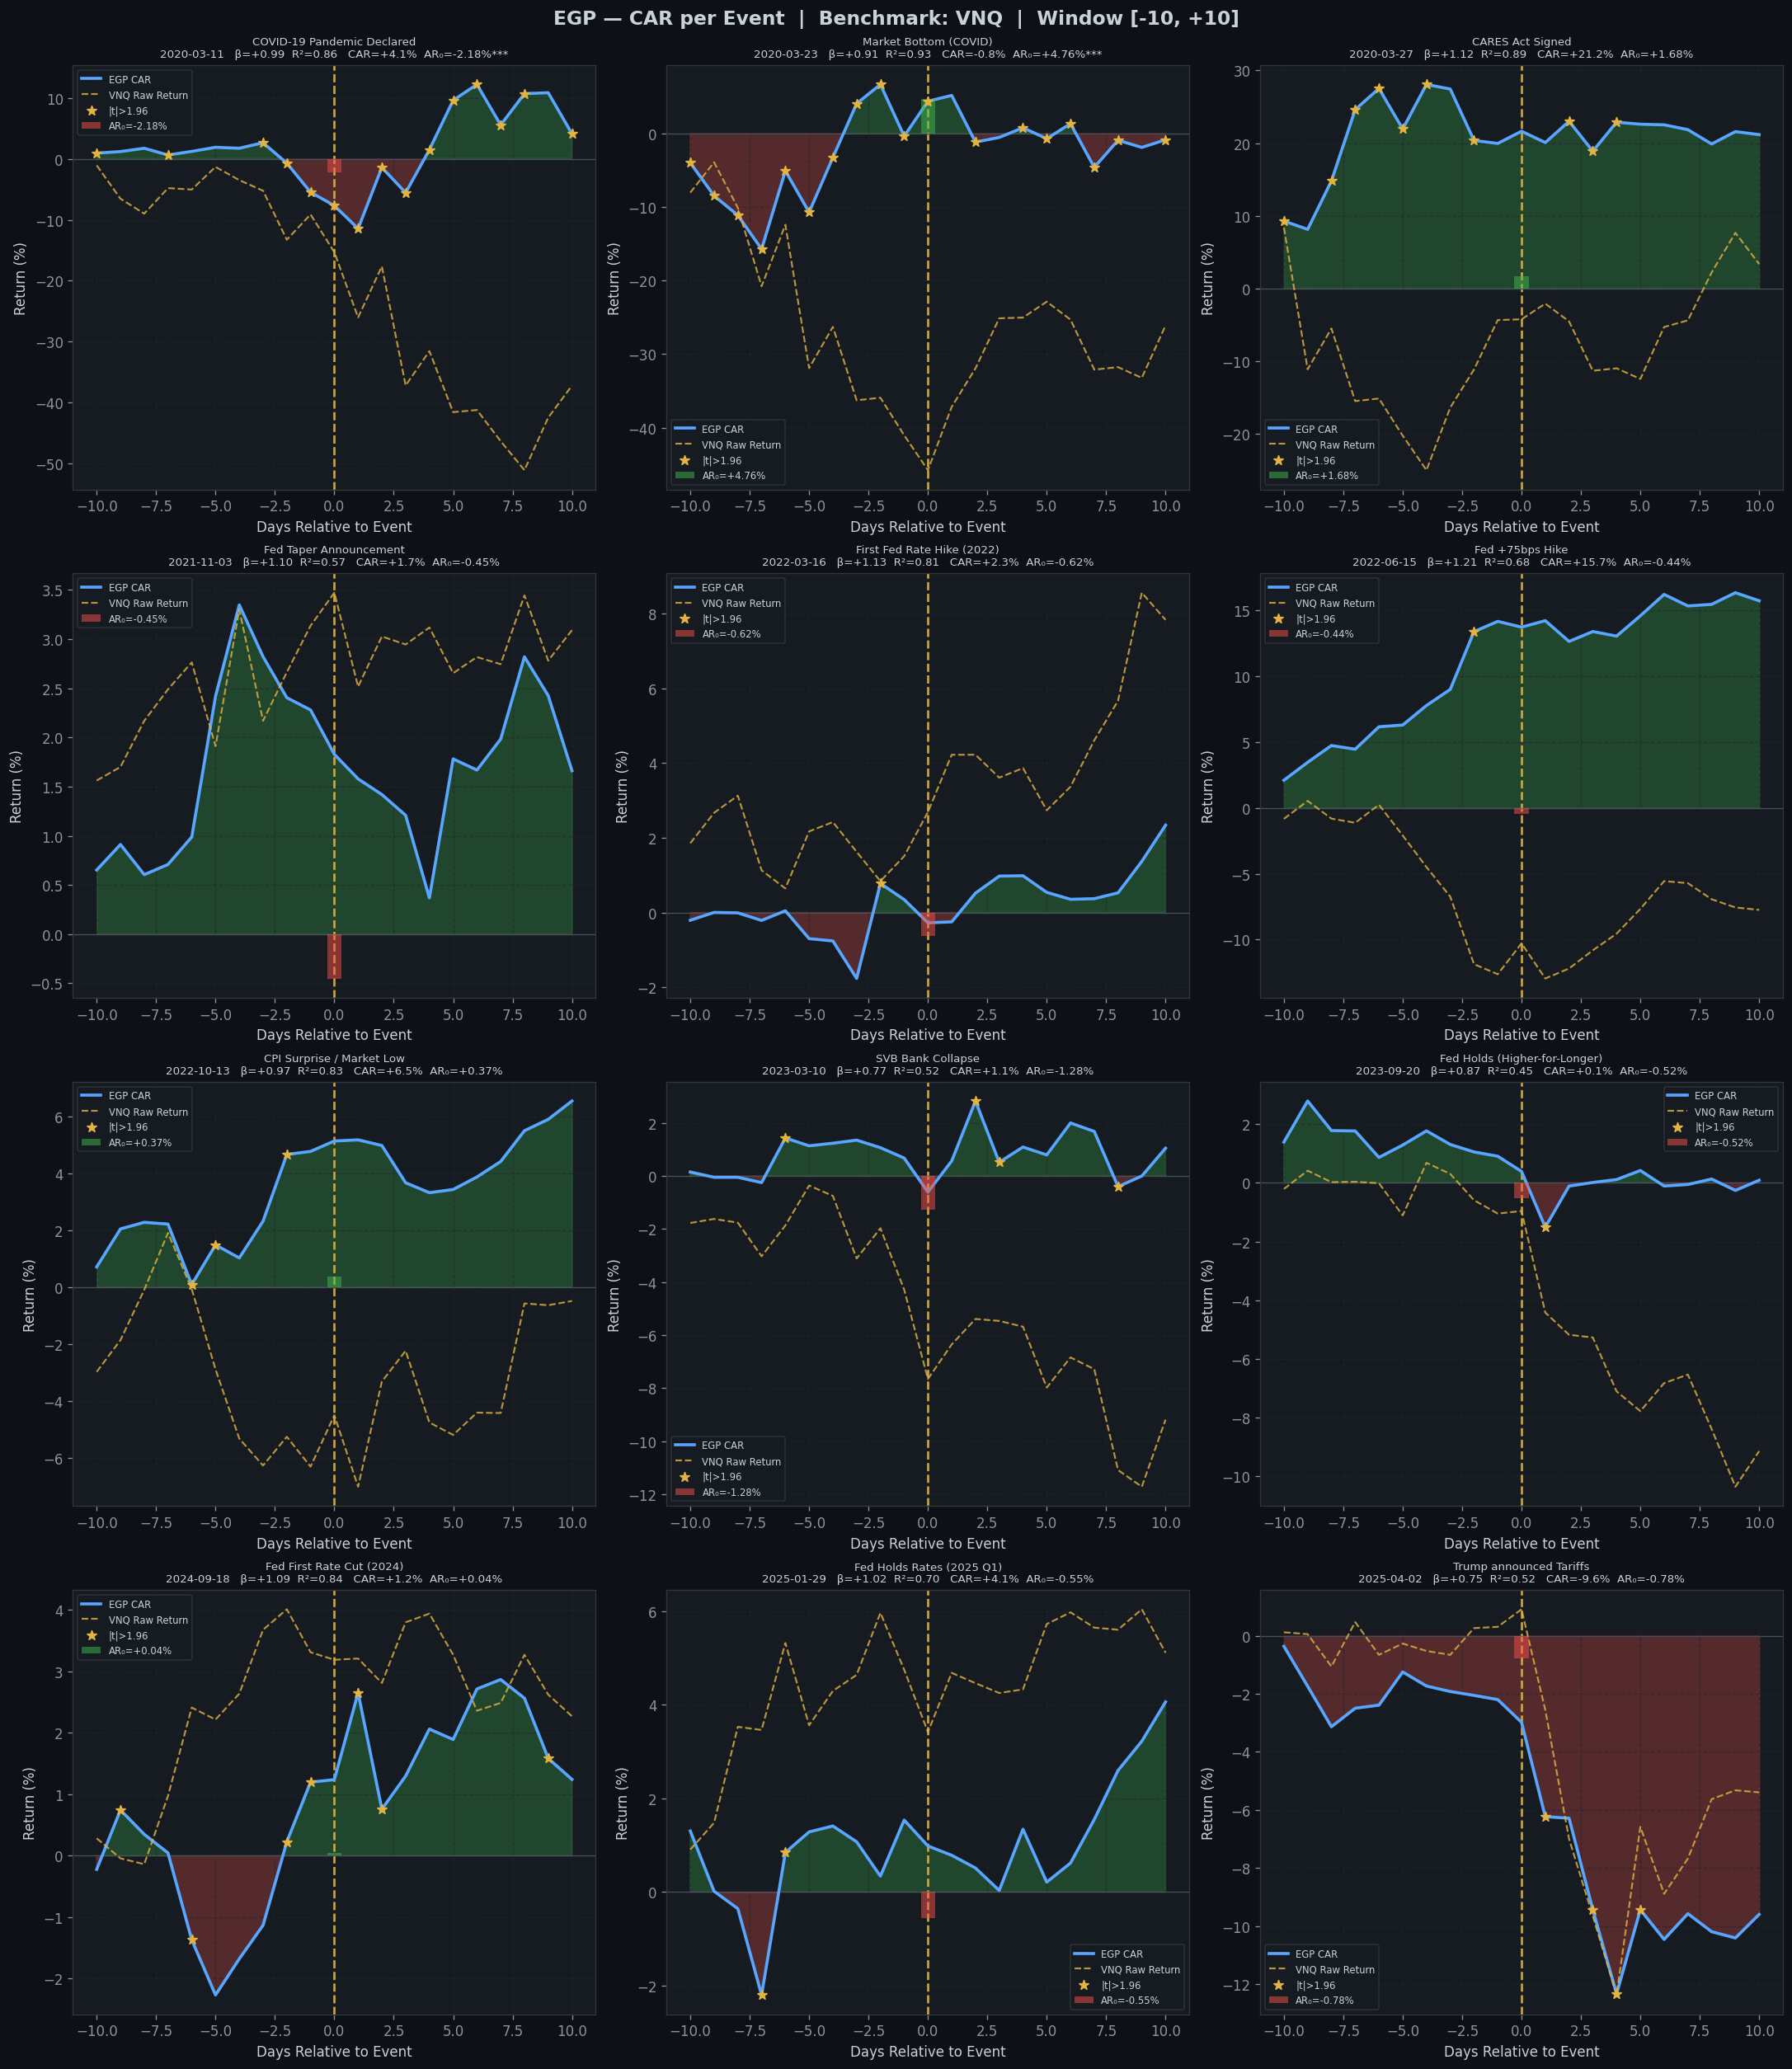

✅ CAR per-event chart saved → EGP_CAR_Events.png


In [14]:
n      = len(results)
ncols  = 3
nrows  = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5.2), constrained_layout=True)
fig.suptitle(
    f'{TICKER} — CAR per Event  |  Benchmark: {BENCHMARK}  |  Window [{-PRE_WINDOW}, +{POST_WINDOW}]',
    fontsize=14, fontweight='bold', color=C['white']
)

flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, (label, r) in enumerate(results.items()):
    ax   = flat[i]
    days = r['relative_days']
    car  = r['CAR']       * 100
    bcar = r['bench_CAR'] * 100     # raw VNQ CAR in event window

    ax.axvline(0, color=C['yellow'], lw=1.6, linestyle='--', alpha=0.9)
    ax.axhline(0, color=C['grey'],   lw=0.8)

    # Shaded fill
    ax.fill_between(days, car, 0, where=(car >= 0),
                    alpha=0.28, color=C['green'], interpolate=True)
    ax.fill_between(days, car, 0, where=(car <  0),
                    alpha=0.28, color=C['red'],   interpolate=True)

    # CAR lines
    ax.plot(days, car,  color=C['blue'],   lw=2.2, label=f'{TICKER} CAR')
    ax.plot(days, bcar, color=C['yellow'], lw=1.3, linestyle='--',
            alpha=0.8, label=f'{BENCHMARK} Raw Return')

    # Significant days
    sig_m = np.abs(r['t_stats']) > 1.96
    if sig_m.any():
        ax.scatter(days[sig_m], car[sig_m],
                   color=C['yellow'], zorder=6, s=50, marker='*',
                   label='|t|>1.96')

    # AR bar at day 0
    ar0     = r['AR_day0'] * 100
    ar0_col = C['green'] if ar0 >= 0 else C['red']
    ax.bar(0, ar0, color=ar0_col, alpha=0.5, width=0.6, zorder=3, label=f'AR₀={ar0:+.2f}%')

    sig_tag = ('***' if abs(r['t_day0'])>2.576 else
               ('**'  if abs(r['t_day0'])>1.960 else
                ('*'   if abs(r['t_day0'])>1.645 else '')))

    ax.set_title(
        f'{label}\n'
        f"{r['event_date'].strftime('%Y-%m-%d')}   "
        f"β={r['beta']:+.2f}  R²={r['r_squared']:.2f}   "
        f"CAR={r['CAR_total']*100:+.1f}%  AR₀={ar0:+.2f}%{sig_tag}",
        fontsize=8, color=C['white']
    )
    ax.set_xlabel('Days Relative to Event')
    ax.set_ylabel('Return (%)')
    ax.legend(fontsize=7)
    ax.grid(True)

for j in range(i + 1, len(flat)):
    flat[j].set_visible(False)

plt.savefig('EGP_CAR_Events.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ CAR per-event chart saved → EGP_CAR_Events.png')

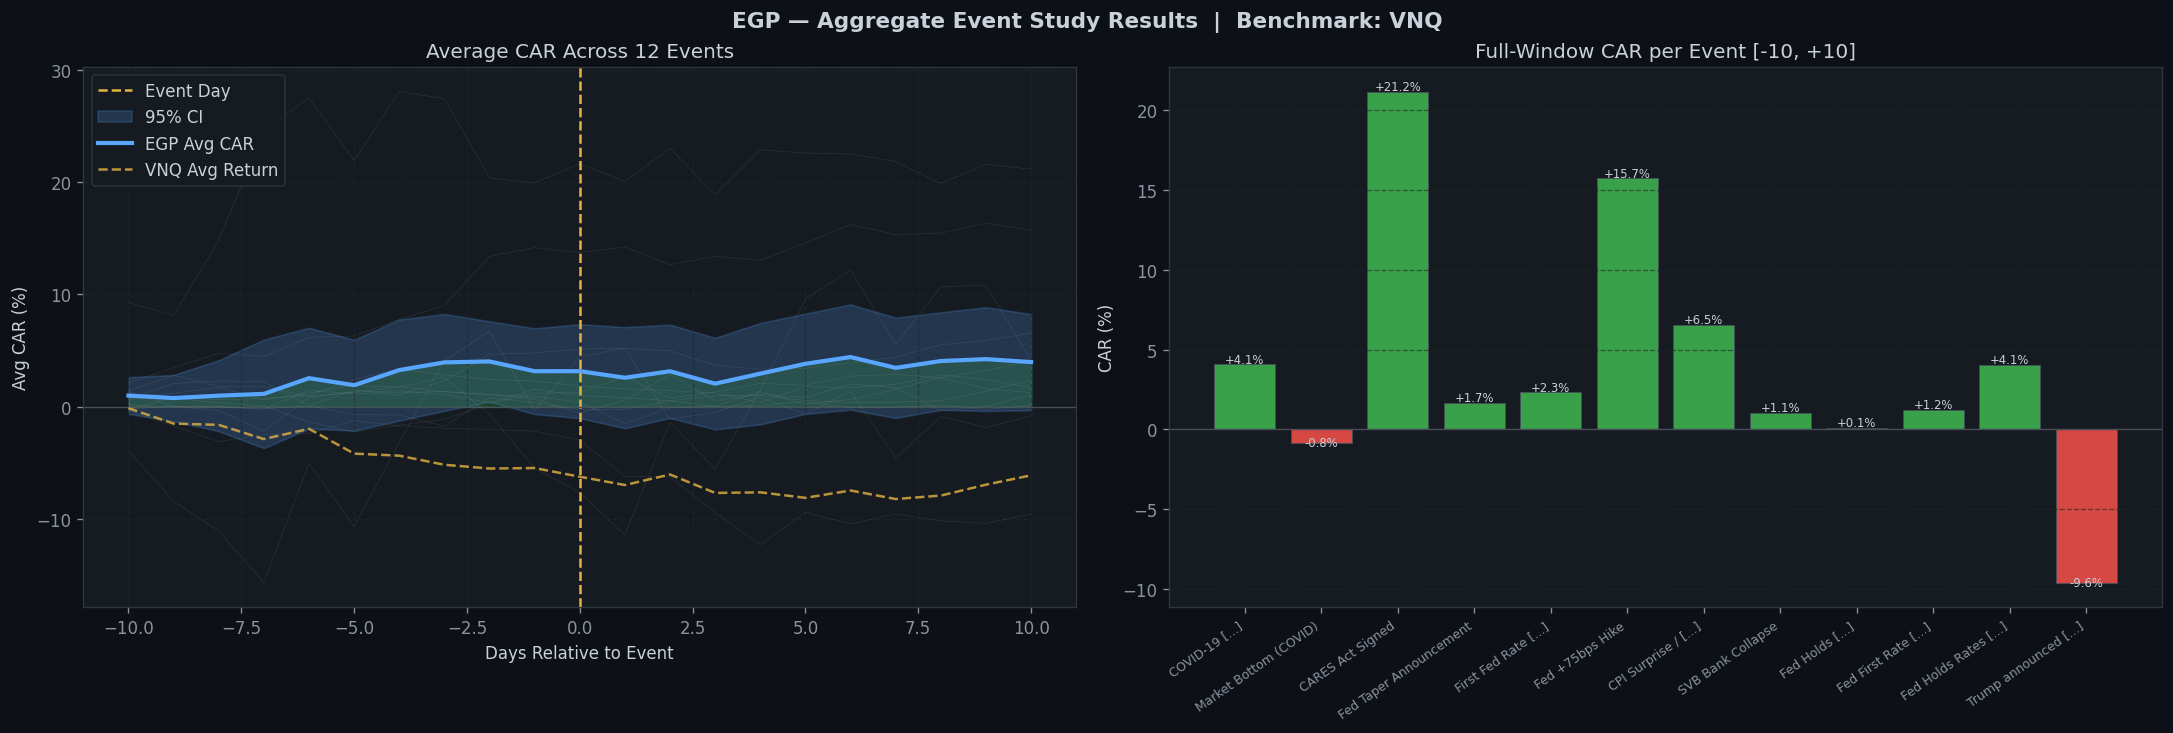

In [18]:
all_cars  = np.array([r['CAR']       for r in results.values()])  # (n_events, window)
all_bcars = np.array([r['bench_CAR'] for r in results.values()])
avg_car   = np.mean(all_cars,  axis=0) * 100
avg_bcar  = np.mean(all_bcars, axis=0) * 100
ci95      = 1.96 * np.std(all_cars, axis=0) * 100 / np.sqrt(len(results))
days      = np.arange(-PRE_WINDOW, POST_WINDOW + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
fig.suptitle(f'{TICKER} — Aggregate Event Study Results  |  Benchmark: {BENCHMARK}',
             fontsize=13, fontweight='bold', color=C['white'])

# ── Average CAR plot ──────────────────────────────────────────────────────────
ax1.axvline(0, color=C['yellow'], lw=1.5, linestyle='--', label='Event Day')
ax1.axhline(0, color=C['grey'],   lw=0.8)
ax1.fill_between(days, avg_car - ci95, avg_car + ci95, alpha=0.2,
                 color=C['blue'], label='95% CI')
ax1.fill_between(days, avg_car, 0, where=(avg_car >= 0),
                 alpha=0.22, color=C['green'], interpolate=True)
ax1.fill_between(days, avg_car, 0, where=(avg_car <  0),
                 alpha=0.22, color=C['red'],   interpolate=True)

# Individual event traces (faint)
for r in results.values():
    ax1.plot(days, r['CAR']*100, color=C['white'], lw=0.4, alpha=0.12)

ax1.plot(days, avg_car,  color=C['blue'],   lw=2.5, label=f'{TICKER} Avg CAR')
ax1.plot(days, avg_bcar, color=C['yellow'], lw=1.5, linestyle='--',
         alpha=0.8, label=f'{BENCHMARK} Avg Return')
ax1.set_title(f'Average CAR Across {len(results)} Events', color=C['white'])
ax1.set_xlabel('Days Relative to Event'); ax1.set_ylabel('Avg CAR (%)')
ax1.legend(); ax1.grid(True)

# ── CAR bar chart per event ───────────────────────────────────────────────────
labels_short = [textwrap.shorten(k, 22) for k in results.keys()]
car_vals     = [r['CAR_total']*100 for r in results.values()]
bar_cols     = [C['green'] if v > 0 else C['red'] for v in car_vals]

bars = ax2.bar(range(len(labels_short)), car_vals,
               color=bar_cols, alpha=0.85, edgecolor=C['grey'], linewidth=0.6)
ax2.axhline(0, color=C['grey'], lw=0.8)
ax2.set_xticks(range(len(labels_short)))
ax2.set_xticklabels(labels_short, rotation=35, ha='right', fontsize=7.5)
ax2.set_title(f'Full-Window CAR per Event [{-PRE_WINDOW}, +{POST_WINDOW}]', color=C['white'])
ax2.set_ylabel('CAR (%)')
ax2.grid(True, axis='y')
for bar, val in zip(bars, car_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.1 if val >= 0 else -0.2),
             f'{val:+.1f}%', ha='center', fontsize=7, color=C['white'])

plt.savefig('EGP_AvgCAR.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

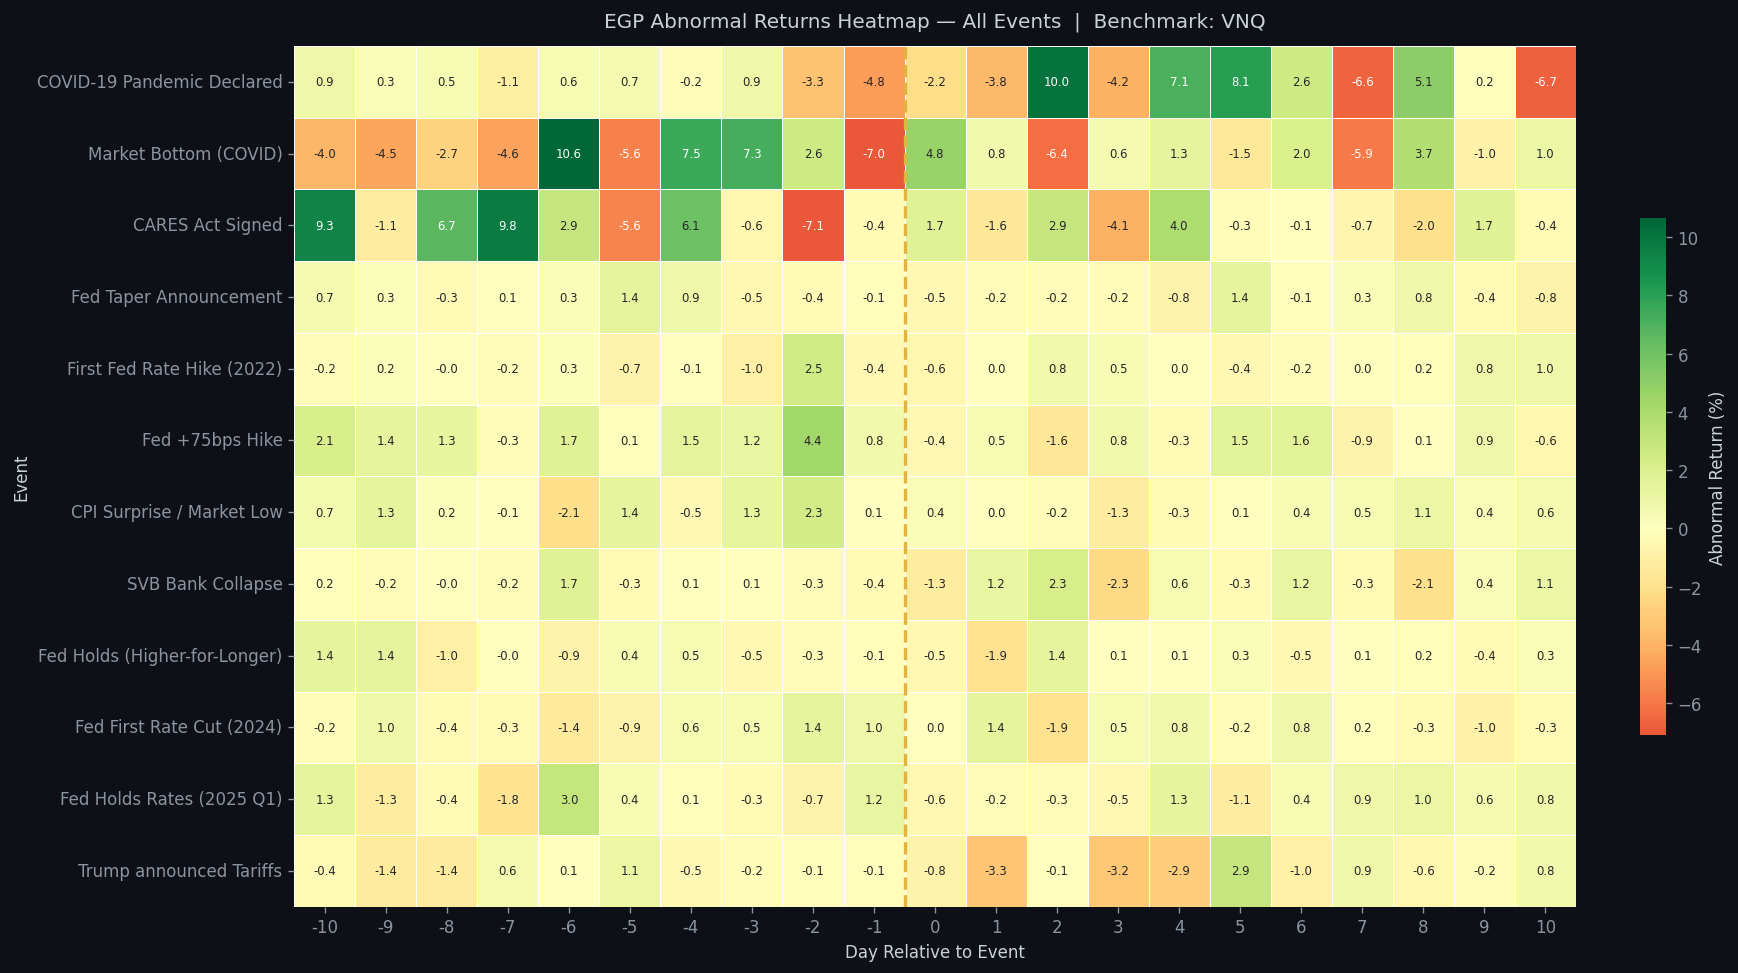

✅ AR heatmap saved → EGP_AR_Heatmap.png


In [21]:
# ── AR Heatmap — time × event ─────────────────────────────────────────────────
ar_matrix = pd.DataFrame(
    {label: r['AR'] * 100 for label, r in results.items()},
    index=np.arange(-PRE_WINDOW, POST_WINDOW + 1)
)

fig, ax = plt.subplots(figsize=(max(12, len(results)*1.2), 8), constrained_layout=True)
sns.heatmap(
    ar_matrix.T, annot=True, fmt='.1f', linewidths=0.4,
    cmap='RdYlGn', center=0, ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Abnormal Return (%)', 'shrink': 0.6}
)
ax.set_title(f'{TICKER} Abnormal Returns Heatmap — All Events  |  Benchmark: {BENCHMARK}',
             fontsize=12, color=C['white'], pad=12)
ax.set_xlabel('Day Relative to Event'); ax.set_ylabel('Event')
ax.axvline(PRE_WINDOW, color=C['yellow'], lw=2.0, linestyle='--')
plt.savefig('EGP_AR_Heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ AR heatmap saved → EGP_AR_Heatmap.png')

In [23]:
# ── Event Study Summary Table ─────────────────────────────────────────────────
rows = []
for label, r in results.items():
    sig = ('***' if abs(r['t_day0'])>2.576 else
           ('**'  if abs(r['t_day0'])>1.960 else
            ('*'   if abs(r['t_day0'])>1.645 else '—')))
    rows.append({
        'Event':           label,
        'Date':            r['event_date'].strftime('%Y-%m-%d'),
        'α (daily)':       f"{r['alpha']*100:+.4f}%",
        'β (vs VNQ)':      f"{r['beta']:+.4f}",
        'R²':              f"{r['r_squared']:.3f}",
        'AR₀':             f"{r['AR_day0']*100:+.2f}%",
        't-stat (AR₀)':    f"{r['t_day0']:+.3f} {sig}",
        'CAR Pre (t₋₁)':  f"{r['CAR'][PRE_WINDOW-1]*100:+.2f}%",
        'CAR Full':        f"{r['CAR_total']*100:+.2f}%",
        'VNQ CAR Full':    f"{r['bench_CAR'][-1]*100:+.2f}%",
        'EGP vs VNQ (α)':  f"{(r['CAR_total'] - r['bench_CAR'][-1])*100:+.2f}%",
        'Verdict':         '🟢 +' if r['CAR_total'] > 0 else '🔴 −',
    })

df_ev = pd.DataFrame(rows).set_index('Event')
display(HTML(df_to_html_table(df_ev, '📋 Event Study Summary Table  (*** p<0.01, ** p<0.05, * p<0.10)')))

Metric,Date,α (daily),β (vs VNQ),R²,AR₀,t-stat (AR₀),CAR Pre (t₋₁),CAR Full,VNQ CAR Full,EGP vs VNQ (α),Verdict
COVID-19 Pandemic Declared,2020-03-11,-0.0447%,+0.9859,0.863,-2.18%,-5.688 ***,-5.50%,+4.09%,-37.18%,+41.27%,🟢 +
Market Bottom (COVID),2020-03-23,-0.0291%,+0.9105,0.931,+4.76%,+9.458 ***,-0.34%,-0.83%,-26.09%,+25.26%,🔴 −
CARES Act Signed,2020-03-27,-0.4125%,+1.1211,0.889,+1.68%,+1.177 —,+19.95%,+21.17%,+3.35%,+17.82%,🟢 +
Fed Taper Announcement,2021-11-03,+0.2364%,+1.1013,0.572,-0.45%,-0.548 —,+2.28%,+1.66%,+3.09%,-1.43%,🟢 +
First Fed Rate Hike (2022),2022-03-16,-0.0783%,+1.1333,0.814,-0.62%,-0.782 —,+0.35%,+2.34%,+7.83%,-5.49%,🟢 +
Fed +75bps Hike,2022-06-15,-0.4878%,+1.2088,0.684,-0.44%,-0.260 —,+14.16%,+15.73%,-7.74%,+23.47%,🟢 +
CPI Surprise / Market Low,2022-10-13,+0.0036%,+0.9734,0.826,+0.37%,+0.518 —,+4.77%,+6.54%,-0.49%,+7.04%,🟢 +
SVB Bank Collapse,2023-03-10,+0.0767%,+0.7666,0.521,-1.28%,-1.535 —,+0.68%,+1.05%,-9.19%,+10.24%,🟢 +
Fed Holds (Higher-for-Longer),2023-09-20,+0.0972%,+0.8707,0.450,-0.52%,-0.656 —,+0.91%,+0.09%,-9.15%,+9.24%,🟢 +
Fed First Rate Cut (2024),2024-09-18,-0.2605%,+1.0904,0.844,+0.04%,+0.087 —,+1.20%,+1.24%,+2.27%,-1.03%,🟢 +


In [25]:
np.random.seed(42)

mu_d    = egp_ret.mean()
sigma_d = egp_ret.std()
dt      = 1   # 1 trading day

print(f'  Historical daily μ:  {mu_d*100:.5f}%  (ann. {mu_d*252*100:.2f}%)')
print(f'  Historical daily σ:  {sigma_d*100:.5f}%  (ann. {sigma_d*np.sqrt(252)*100:.2f}%)')
print(f'  Starting price:      ${INITIAL_PRICE:.2f}')
print(f'  Running {N_SIMULATIONS:,} simulations × {FORECAST_DAYS} days ...', end=' ')

# GBM shocks
Z      = np.random.standard_normal((N_SIMULATIONS, FORECAST_DAYS))
shocks = (mu_d - 0.5 * sigma_d**2) * dt + sigma_d * np.sqrt(dt) * Z

# Build price paths
price_paths = INITIAL_PRICE * np.exp(np.cumsum(shocks, axis=1))
price_paths = np.hstack([np.full((N_SIMULATIONS, 1), INITIAL_PRICE), price_paths])

final_prices  = price_paths[:, -1]
final_returns = (final_prices / INITIAL_PRICE - 1) * 100

print('done!')
print(f'\n  Median end price  : ${np.median(final_prices):,.2f}')
print(f'  Mean end price    : ${np.mean(final_prices):,.2f}')
print(f'  5th  pct price    : ${np.percentile(final_prices, 5):,.2f}')
print(f'  95th pct price    : ${np.percentile(final_prices, 95):,.2f}')

  Historical daily μ:  0.03542%  (ann. 8.93%)
  Historical daily σ:  1.94823%  (ann. 30.93%)
  Starting price:      $190.64
  Running 10,000 simulations × 252 days ... done!

  Median end price  : $198.12
  Mean end price    : $207.77
  5th  pct price    : $118.59
  95th pct price    : $328.18


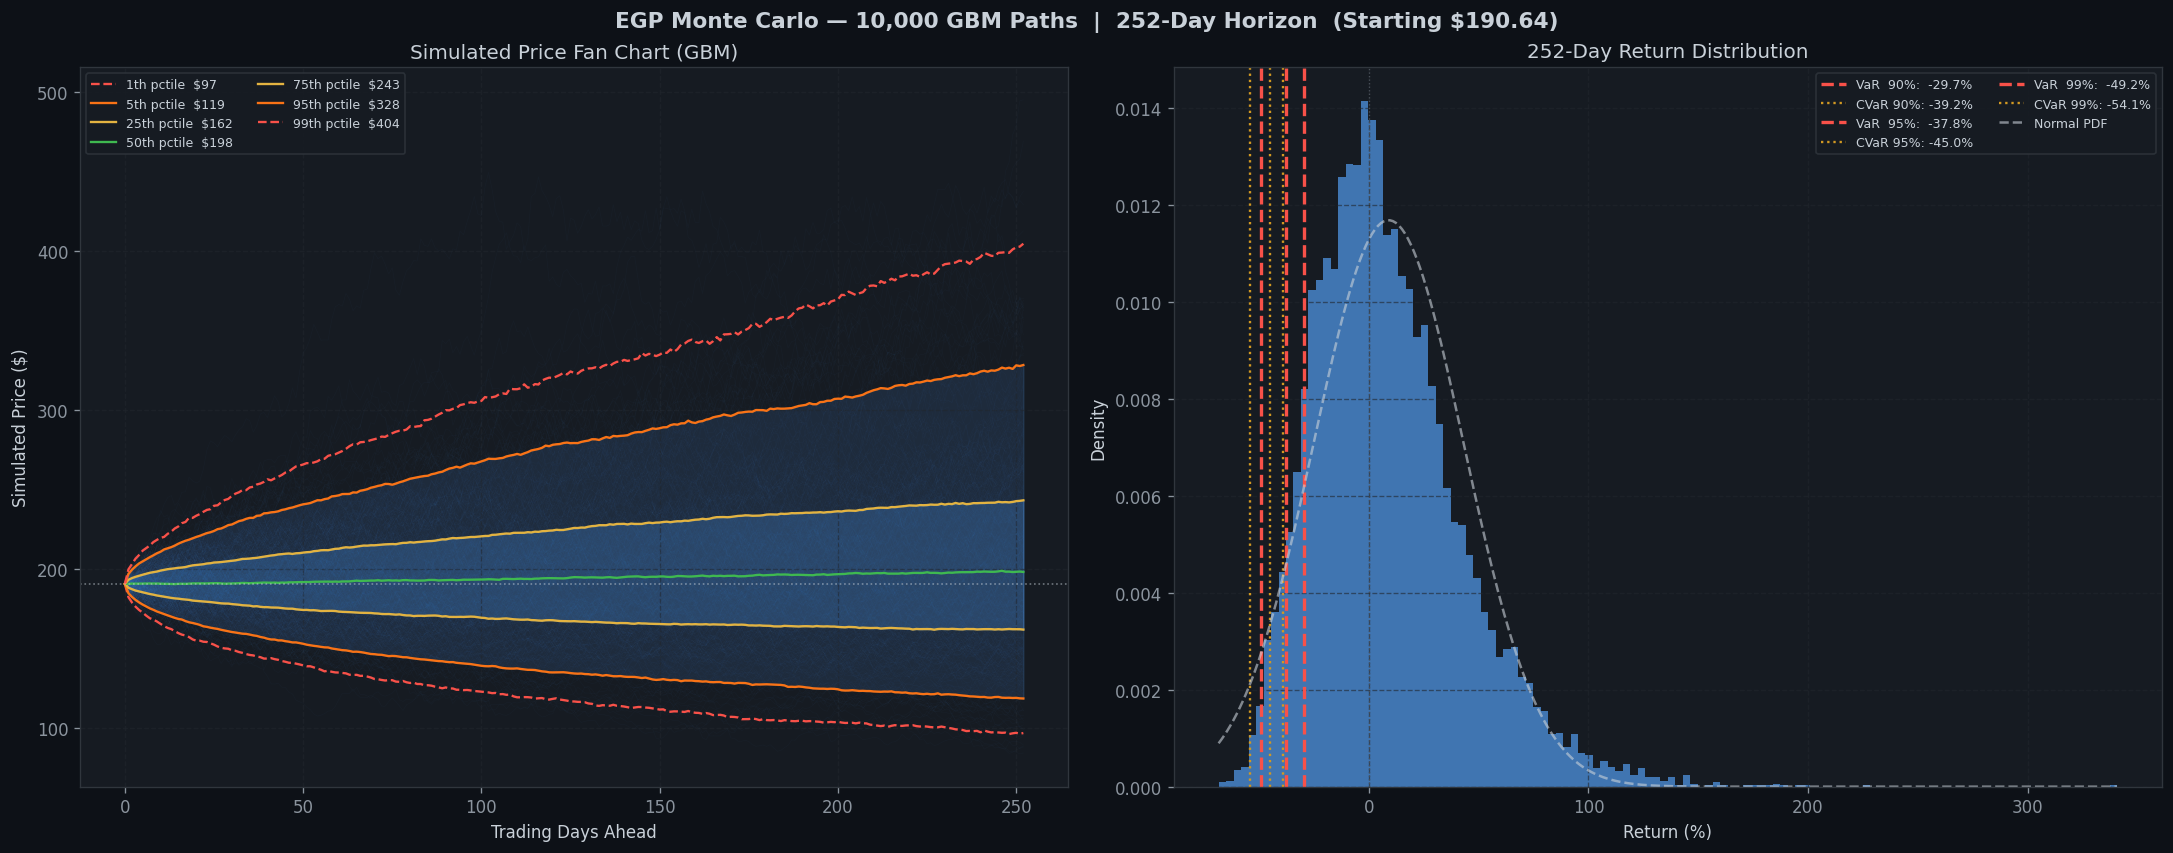

✅ Monte Carlo chart saved → EGP_MonteCarlo.png


In [27]:
t_axis = np.arange(FORECAST_DAYS + 1)
pcts   = [1, 5, 25, 50, 75, 95, 99]
pct_paths = {p: np.percentile(price_paths, p, axis=0) for p in pcts}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
fig.suptitle(
    f'{TICKER} Monte Carlo — {N_SIMULATIONS:,} GBM Paths  |  {FORECAST_DAYS}-Day Horizon  '
    f'(Starting ${INITIAL_PRICE:.2f})',
    fontsize=13, fontweight='bold', color=C['white']
)

# ── Fan chart ─────────────────────────────────────────────────────────────────
ax = axes[0]
sample = np.random.choice(N_SIMULATIONS, 400, replace=False)
for i in sample:
    ax.plot(t_axis, price_paths[i], color=C['blue'], alpha=0.025, lw=0.5)

# Shaded bands
ax.fill_between(t_axis, pct_paths[5],  pct_paths[95], alpha=0.12, color=C['blue'])
ax.fill_between(t_axis, pct_paths[25], pct_paths[75], alpha=0.22, color=C['blue'])

band_conf = {1: C['red'], 5: '#f97316', 25: C['yellow'],
             50: C['green'], 75: C['yellow'], 95: '#f97316', 99: C['red']}
for p, clr in band_conf.items():
    ax.plot(t_axis, pct_paths[p], lw=1.4, color=clr,
            linestyle='--' if p in [1, 99] else '-',
            label=f'{p}th pctile  ${pct_paths[p][-1]:,.0f}')

ax.axhline(INITIAL_PRICE, color=C['white'], lw=1, linestyle=':', alpha=0.5)
ax.set_title('Simulated Price Fan Chart (GBM)', color=C['white'])
ax.set_xlabel('Trading Days Ahead')
ax.set_ylabel('Simulated Price ($)')
ax.legend(fontsize=7.5, ncol=2)
ax.grid(True)

# ── Return distribution ───────────────────────────────────────────────────────
ax = axes[1]
ax.hist(final_returns, bins=120, density=True,
        color=C['blue'], alpha=0.65, edgecolor='none')

for lv in VaR_LEVELS:
    v   = np.percentile(final_returns, (1-lv)*100)
    cv  = final_returns[final_returns <= v].mean()
    ax.axvline(v,  color=C['red'],    lw=2.0, linestyle='--',
               label=f'VaR  {lv*100:.0f}%:  {v:+.1f}%')
    ax.axvline(cv, color=C['orange'], lw=1.4, linestyle=':',
               label=f'CVaR {lv*100:.0f}%: {cv:+.1f}%')

# Fit normal
x_range = np.linspace(final_returns.min(), final_returns.max(), 300)
ax.plot(x_range,
        stats.norm.pdf(x_range, final_returns.mean(), final_returns.std()),
        color=C['white'], lw=1.5, linestyle='--', alpha=0.6, label='Normal PDF')

ax.axvline(0, color=C['grey'], lw=0.8, linestyle=':')
ax.set_title(f'{FORECAST_DAYS}-Day Return Distribution', color=C['white'])
ax.set_xlabel('Return (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=7.5, ncol=2)
ax.grid(True)

plt.savefig('EGP_MonteCarlo.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Monte Carlo chart saved → EGP_MonteCarlo.png')

In [29]:
# ── Historical drawdown ───────────────────────────────────────────────────────
roll_max    = egp_close.cummax()
drawdown    = (egp_close - roll_max) / roll_max * 100
max_dd      = drawdown.min()
max_dd_date = drawdown.idxmin()
avg_dd      = drawdown[drawdown < 0].mean()
pct_in_dd   = (drawdown < 0).mean() * 100

# ── Build risk table ──────────────────────────────────────────────────────────
risk_rows = []
for lv in VaR_LEVELS:
    pct_tail     = (1 - lv) * 100
    # MC
    mc_var       = np.percentile(final_returns, pct_tail)
    mc_cvar      = final_returns[final_returns <= mc_var].mean()
    # Historical (daily, annualised)
    h_var_d      = np.percentile(egp_ret, pct_tail) * 100
    h_cvar_d     = egp_ret[egp_ret <= np.percentile(egp_ret, pct_tail)].mean() * 100
    h_var_ann    = h_var_d  * np.sqrt(252)
    h_cvar_ann   = h_cvar_d * np.sqrt(252)
    risk_rows.append({
        'Confidence': f'{lv*100:.0f}%',
        'MC VaR (1yr)':      f'{mc_var:+.2f}%  = ${INITIAL_PRICE*mc_var/100:+,.2f}',
        'MC CVaR (1yr)':     f'{mc_cvar:+.2f}%  = ${INITIAL_PRICE*mc_cvar/100:+,.2f}',
        'Hist VaR (daily)':  f'{h_var_d:+.4f}%',
        'Hist CVaR (daily)': f'{h_cvar_d:+.4f}%',
        'Hist VaR (ann)':    f'{h_var_ann:+.2f}%',
        'Hist CVaR (ann)':   f'{h_cvar_ann:+.2f}%',
    })

df_risk = pd.DataFrame(risk_rows).set_index('Confidence')

display(HTML(f'<h4>📉 VaR / CVaR Table — {TICKER}  |  Starting price ${INITIAL_PRICE:.2f}</h4>'))
display(df_risk.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color','#21262d'),('color','#c9d1d9'),('padding','7px 10px')]},
    {'selector': 'td', 'props': [('background-color','#161b22'),('color','#c9d1d9'),('padding','5px 10px')]},
]))

print(f'\n  📉 Drawdown Summary')
print(f'  Max Drawdown     : {max_dd:+.2f}%  (on {max_dd_date.strftime("%Y-%m-%d")})')
print(f'  Avg Drawdown     : {avg_dd:+.2f}%')
print(f'  % Days in DD     : {pct_in_dd:.1f}%')
print(f'\n  🎰 Monte Carlo Probabilities')
print(f'  P(loss > 0%)     : {(final_returns < 0).mean()*100:.1f}%')
print(f'  P(loss > 10%)    : {(final_returns < -10).mean()*100:.1f}%')
print(f'  P(loss > 20%)    : {(final_returns < -20).mean()*100:.1f}%')
print(f'  P(gain > 10%)    : {(final_returns > 10).mean()*100:.1f}%')
print(f'  P(gain > 20%)    : {(final_returns > 20).mean()*100:.1f}%')

AttributeError: The '.style' accessor requires jinja2

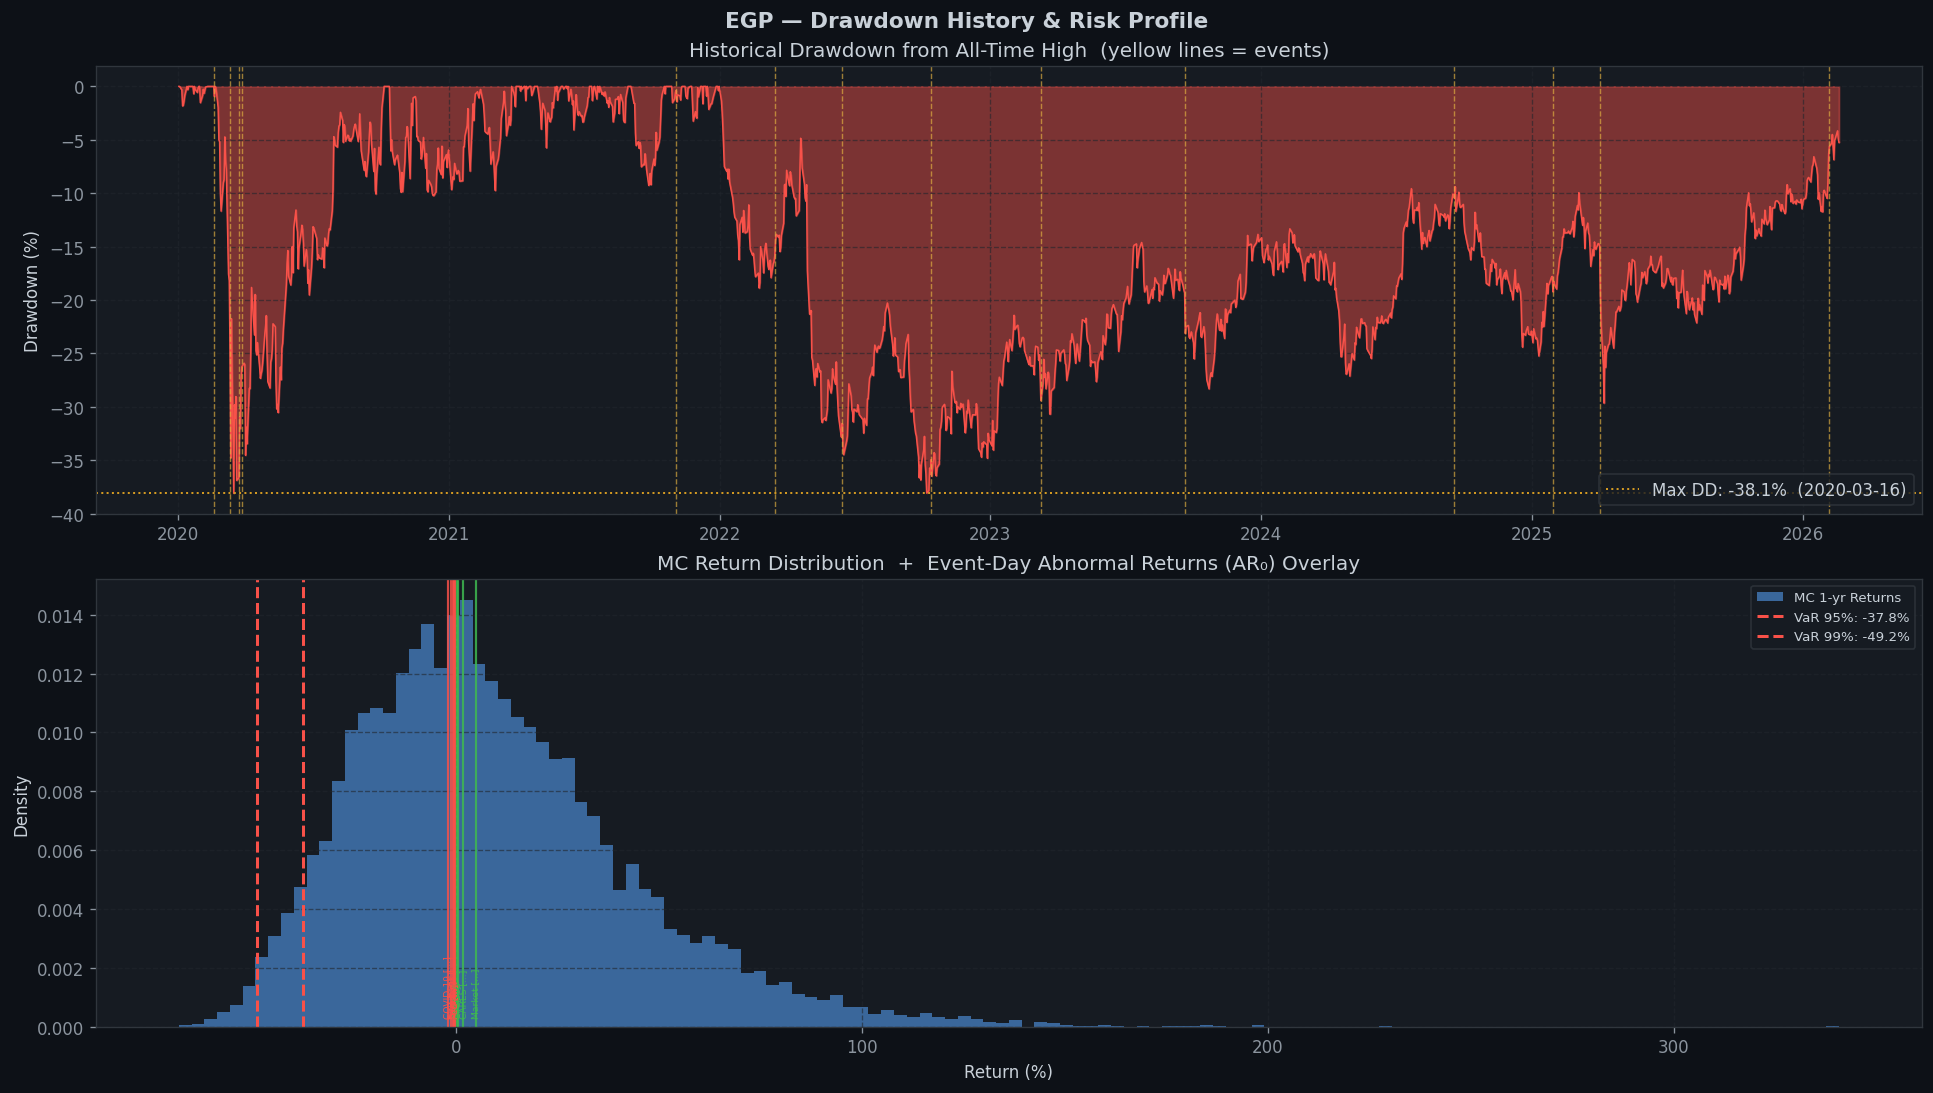

✅ Drawdown & risk chart saved → EGP_Drawdown_Risk.png


In [31]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
fig.suptitle(f'{TICKER} — Drawdown History & Risk Profile', fontsize=13,
             fontweight='bold', color=C['white'])

# ── Drawdown ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(drawdown.index, drawdown, 0, color=C['red'], alpha=0.45)
ax.plot(drawdown.index, drawdown, color=C['red'], lw=0.9)
for dt_str in EVENTS:
    dt = pd.Timestamp(dt_str)
    if egp_close.index[0] <= dt <= egp_close.index[-1]:
        ax.axvline(dt, color=C['yellow'], lw=0.85, alpha=0.65, linestyle='--')
ax.axhline(max_dd, color=C['orange'], lw=1.2, linestyle=':',
           label=f'Max DD: {max_dd:.1f}%  ({max_dd_date.strftime("%Y-%m-%d")})')
ax.set_title('Historical Drawdown from All-Time High  (yellow lines = events)', color=C['white'])
ax.set_ylabel('Drawdown (%)')
ax.legend(); ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── MC final return distribution + event AR overlay ───────────────────────────
ax = axes[1]
ax.hist(final_returns, bins=130, density=True,
        color=C['blue'], alpha=0.55, edgecolor='none', label='MC 1-yr Returns')

for lv in [0.95, 0.99]:
    v = np.percentile(final_returns, (1-lv)*100)
    ax.axvline(v, color=C['red'], lw=1.8, linestyle='--',
               label=f'VaR {lv*100:.0f}%: {v:+.1f}%')

# Plot event-day AR₀ as vertical lines
for label, r in results.items():
    ev_ar = r['AR_day0'] * 100
    col   = C['green'] if ev_ar >= 0 else C['red']
    ax.axvline(ev_ar, color=col, lw=1.3, alpha=0.85)
    ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.05
    ax.annotate(
        textwrap.shorten(label, 14),
        xy=(ev_ar, ymax * 0.02),
        fontsize=5.5, color=col,
        rotation=90, va='bottom', ha='center'
    )

ax.set_title('MC Return Distribution  +  Event-Day Abnormal Returns (AR₀) Overlay',
             color=C['white'])
ax.set_xlabel('Return (%)'); ax.set_ylabel('Density')
ax.legend(fontsize=8); ax.grid(True)

plt.savefig('EGP_Drawdown_Risk.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Drawdown & risk chart saved → EGP_Drawdown_Risk.png')